<div style="font-size: 30px; line-height: 1.25;">1) Imports e ambiente</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Importa de uma vez as bibliotecas usadas no notebook: pathlib e warnings, pandas e numpy, matplotlib e seaborn, scipy, sklearn para imputação e o display do IPython para mostrar tabelas e texto nas células. O código seguinte só usa esses pacotes, sem voltar a importar.</div>


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn.impute import SimpleImputer

<div style="font-size: 30px; line-height: 1.25;">2) Carregamento do CSV</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Define o caminho do arquivo dataset_balanceado.csv relativo à pasta do notebook e lê todas as linhas num DataFrame do pandas com low_memory=False para inferência de tipos mais estável em arquivo grande. A variável do DataFrame passa a guardar o conjunto inteiro para o restante da análise.</div>


In [2]:
DATASET_PATH = Path("../dataset_balanceado.csv")
df = pd.read_csv(DATASET_PATH, low_memory=False)

<div style="font-size: 30px; line-height: 1.25;">3) Dicionário das colunas</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Monta uma tabela de referência com nome técnico de cada campo do log, um título curto e uma frase de explicação, e exibe com display. Serve só como glossário para leitura humana, não altera os dados.</div>


In [3]:
colunas_info = [
    ("ts", "Timestamp da conexão", "Momento em que a conexão começou"),
    ("uid", "Identificador único da conexão", "ID interno gerado pelo Zeek"),
    ("id.orig_h", "IP de origem", "Máquina que iniciou a conexão"),
    ("id.orig_p", "Porta de origem", "Porta usada pelo cliente/origem"),
    ("id.resp_h", "IP de destino", "Máquina que respondeu"),
    ("id.resp_p", "Porta de destino", "Porta do serviço alvo"),
    ("proto", "Protocolo de transporte", "TCP, UDP, ICMP"),
    ("service", "Serviço identificado", "HTTP, DNS, SSH, DHCP etc"),
    ("duration", "Duração da conexão", "Tempo total do flow"),
    ("orig_bytes", "Bytes enviados pela origem", "Quantidade de dados enviados pelo cliente"),
    ("resp_bytes", "Bytes enviados pela resposta", "Quantidade de dados retornados"),
    ("conn_state", "Estado da conexão", "Resultado/finalização da conexão"),
    ("local_orig", "Origem é local?", "Booleano"),
    ("local_resp", "Destino é local?", "Booleano"),
    ("missed_bytes", "Bytes perdidos na captura", "Pacotes não capturados"),
    ("history", "Histórico de flags TCP", "Sequência resumida de eventos TCP"),
    ("orig_pkts", "Pacotes enviados pela origem", "Quantidade de pacotes"),
    ("orig_ip_bytes", "Bytes IP enviados pela origem", "Inclui headers IP"),
    ("resp_pkts", "Pacotes enviados pela resposta", "Quantidade de pacotes"),
    ("resp_ip_bytes", "Bytes IP enviados pela resposta", "Inclui headers IP"),
    ("tunnel_parents", "Informações de tunelamento", "Normalmente vazio"),
    ("label", "Classe principal", "Benign ou Malicious"),
    ("detailed-label", "Tipo específico do ataque", "Mirai, C&C, DDoS, Scan etc"),
]

tabela_colunas = pd.DataFrame(colunas_info, columns=["coluna", "significado", "descrição"])
display(tabela_colunas)

,coluna,significado,descrição
0,ts,Timestamp da conexão,Momento em que a conexão começou
1,uid,Identificador único da conexão,ID interno gerado pelo Zeek
2,id.orig_h,IP de origem,Máquina que iniciou a conexão
3,id.orig_p,Porta de origem,Porta usada pelo cliente/origem
4,id.resp_h,IP de destino,Máquina que respondeu
5,id.resp_p,Porta de destino,Porta do serviço alvo
6,proto,Protocolo de transporte,"TCP, UDP, ICMP"
7,service,Serviço identificado,"HTTP, DNS, SSH, DHCP etc"
8,duration,Duração da conexão,Tempo total do flow
9,orig_bytes,Bytes enviados pela origem,Quantidade de dados enviados pelo cliente


<div style="font-size: 30px; line-height: 1.25;">4) Primeira exploração</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Imprime dimensões, lista de colunas, dtypes e info, conta nulos por coluna com percentagem, inspeciona colunas categóricas à procura de vazio e sentinels Zeek, mostra cardinalidade e estatísticas descritivas das numéricas e describe das categóricas escolhidas.</div>


In [4]:
print("Dimensão")
print(len(df), "linhas,", df.shape[1], "colunas")

print("\nColunas")
for nome in df.columns:
    print("-", nome)

print("\nDtypes")
print(df.dtypes)

print("\nInfo")
df.info(memory_usage=False)

print("\nNulos (NaN)")
nan_count = df.isna().sum()
nan_pct = (nan_count / len(df) * 100).round(4)
tbl_nulos = pd.DataFrame({"nan": nan_count, "pct": nan_pct})
tbl_nulos = tbl_nulos[tbl_nulos["nan"] > 0].sort_values("nan", ascending=False)
if tbl_nulos.empty:
    print("Nenhum NaN.")
else:
    print(tbl_nulos.to_string())

colunas_categoricas = [
    "id.orig_h",
    "id.resp_h",
    "proto",
    "conn_state",
    "history",
    "label",
    "detailed-label",
    "scenario",
]
cats = [c for c in colunas_categoricas if c in df.columns]

print("\nColunas categóricas")
for c in cats:
    print("-", c)

print("\nStrings vazias após strip (dataset completo)")
for col in cats:
    s = df[col].astype(str)
    n_blank = int((s.str.strip() == "").sum())
    if n_blank:
        print(col, n_blank)

print("\nSentinels Zeek \"-\" e \"(empty)\" (dataset completo)")
for col in cats:
    s = df[col].astype(str).str.strip()
    for sent in ("-", "(empty)"):
        n = int((s == sent).sum())
        if n:
            print(col, repr(sent), n)

print("\nValores distintos por coluna")
print(df.nunique(dropna=False).sort_values(ascending=False).to_string())

nums = df.select_dtypes(include=["number"]).columns.tolist()
if nums:
    print("\nDescribe numéricas")
    print(df[nums].describe().T.to_string())

if cats:
    print("\nDescribe colunas categóricas")
    print(df[cats].describe().T.to_string())


Dimensão
16457968 linhas, 24 colunas

Colunas
- ts
- uid
- id.orig_h
- id.orig_p
- id.resp_h
- id.resp_p
- proto
- service
- duration
- orig_bytes
- resp_bytes
- conn_state
- local_orig
- local_resp
- missed_bytes
- history
- orig_pkts
- orig_ip_bytes
- resp_pkts
- resp_ip_bytes
- tunnel_parents
- label
- detailed-label
- scenario

Dtypes
ts                float64
uid                   str
id.orig_h             str
id.orig_p           int64
id.resp_h             str
id.resp_p           int64
proto                 str
service               str
duration              str
orig_bytes            str
resp_bytes            str
conn_state            str
local_orig            str
local_resp            str
missed_bytes        int64
history               str
orig_pkts           int64
orig_ip_bytes       int64
resp_pkts           int64
resp_ip_bytes       int64
tunnel_parents        str
label                 str
detailed-label        str
scenario              str
dtype: object

Info
<class 'pandas.

<div style="font-size: 30px; line-height: 1.25;">5) Normalização do rótulo</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Mostra a distribuição da coluna label, padroniza variantes escritas como benign para o texto Benign ignorando maiúsculas e espaços extras, e imprime de novo a distribuição para conferir que a classe benigna ficou uniforme.</div>


In [5]:
print("label antes:")
print(df["label"].astype(str).str.strip().value_counts())

mask = df["label"].astype(str).str.strip().str.lower() == "benign"
df.loc[mask, "label"] = "Benign"

print("\nlabel depois:")
print(df["label"].astype(str).str.strip().value_counts())


label antes:
label
Malicious    13993698
Benign        2462444
benign           1826
Name: count, dtype: int64

label depois:
label
Malicious    13993698
Benign        2464270
Name: count, dtype: int64


<div style="font-size: 30px; line-height: 1.25;">6) Diagnóstico de ausências</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Para cada coluna conta nulos reais e, em texto, também string vazia após strip, traço e marcador empty entre parênteses; ordena por total de problemas e desenha barras horizontais com o percentual de linhas afetadas por coluna.</div>


        coluna  nan  vazio_strip  dash_zeek  empty_zeek    total      pct
    local_orig    0            0   16457968           0 16457968 100.0000
    local_resp    0            0   16457968           0 16457968 100.0000
       service    0            0   16426647           0 16426647  99.8097
tunnel_parents    0            0   15349379     1042863 16392242  99.6006
      duration    0            0   11693325           0 11693325  71.0496
    resp_bytes    0            0   11693325           0 11693325  71.0496
    orig_bytes    0            0   11693325           0 11693325  71.0496
detailed-label    0            0    2464270           0  2464270  14.9731
       history    0            0      32958           0    32958   0.2003
         proto    0            0          0           0        0   0.0000
     id.resp_h    0            0          0           0        0   0.0000
     id.resp_p    0            0          0           0        0   0.0000
           uid    0            0      

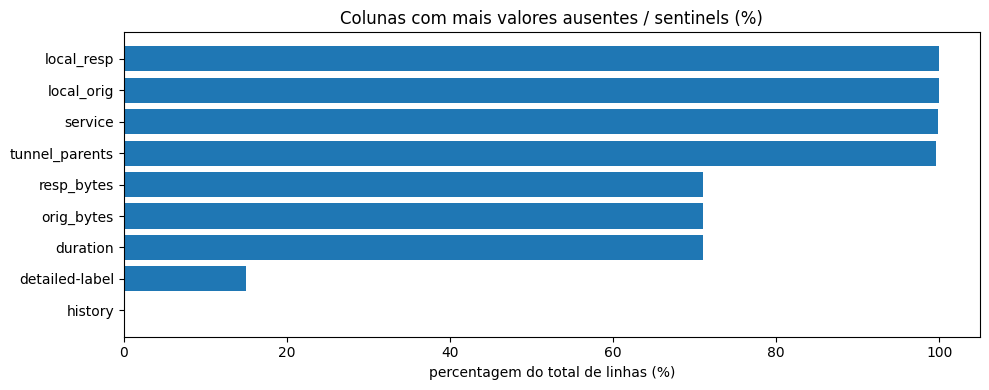

In [6]:
n = len(df)
linhas = []
for col in df.columns:
    serie = df[col]
    n_nan = int(serie.isna().sum())
    if pd.api.types.is_numeric_dtype(serie):
        n_vazio = 0
        n_dash = 0
        n_empty_paren = 0
    else:
        s = serie.astype(str).str.strip()
        n_vazio = int(s.eq("").sum())
        n_dash = int(s.eq("-").sum())
        n_empty_paren = int(s.eq("(empty)").sum())
    total = n_nan + n_vazio + n_dash + n_empty_paren
    pct = round(100 * total / n, 4) if n else 0.0
    linhas.append(
        {
            "coluna": col,
            "nan": n_nan,
            "vazio_strip": n_vazio,
            "dash_zeek": n_dash,
            "empty_zeek": n_empty_paren,
            "total": total,
            "pct": pct,
        }
    )

tbl = pd.DataFrame(linhas).sort_values("total", ascending=False)
print(tbl.to_string(index=False))

com_problema = tbl[tbl["total"] > 0]
if com_problema.empty:
    print("Sem NaN, vazios nem sentinels Zeek '-' / '(empty)'.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(com_problema))))
    ordem = com_problema.sort_values("pct", ascending=True)
    ax.barh(ordem["coluna"].astype(str), ordem["pct"])
    ax.set_xlabel("percentagem do total de linhas (%)")
    ax.set_title("Colunas com mais valores ausentes / sentinels (%)")
    plt.tight_layout()
    plt.show()


<div style="font-size: 30px; line-height: 1.25;">7) Remoção de colunas</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Remove as colunas local_orig, local_resp, service e tunnel_parents quando existem, imprime nova dimensão e lista de colunas e repete o mesmo diagnóstico de ausências e o gráfico percentual para comparar com o passo anterior.</div>


Dimensão após remover local_orig, local_resp, service, tunnel_parents
16457968 linhas, 20 colunas
Colunas: ['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'detailed-label', 'scenario']

Ausências por coluna (após remoção)
        coluna  nan  vazio_strip  dash_zeek  empty_zeek    total     pct
    orig_bytes    0            0   11693325           0 11693325 71.0496
    resp_bytes    0            0   11693325           0 11693325 71.0496
      duration    0            0   11693325           0 11693325 71.0496
detailed-label    0            0    2464270           0  2464270 14.9731
       history    0            0      32958           0    32958  0.2003
     id.orig_h    0            0          0           0        0  0.0000
           uid    0            0          0           0        0  0.0000
            ts   

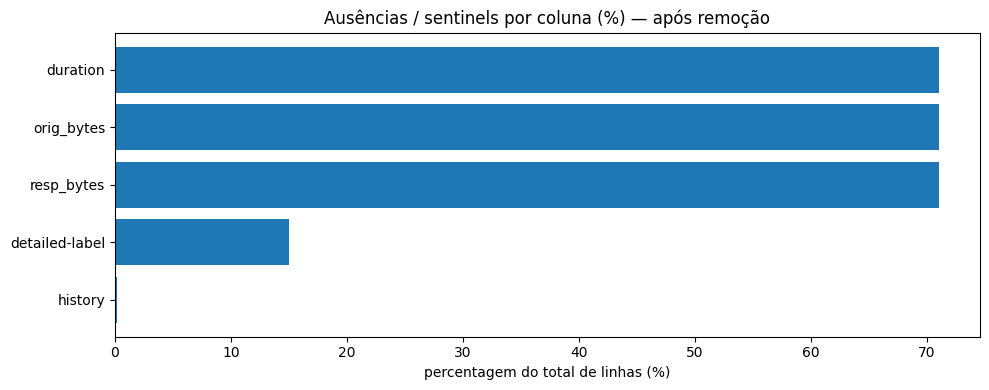

In [7]:
remover = ["local_resp", "local_orig", "service", "tunnel_parents"]
df = df.drop(columns=[c for c in remover if c in df.columns])

print("Dimensão após remover local_orig, local_resp, service, tunnel_parents")
print(len(df), "linhas,", df.shape[1], "colunas")
print("Colunas:", list(df.columns))

n = len(df)
linhas = []
for col in df.columns:
    serie = df[col]
    n_nan = int(serie.isna().sum())
    if pd.api.types.is_numeric_dtype(serie):
        n_vazio = 0
        n_dash = 0
        n_empty_paren = 0
    else:
        s = serie.astype(str).str.strip()
        n_vazio = int(s.eq("").sum())
        n_dash = int(s.eq("-").sum())
        n_empty_paren = int(s.eq("(empty)").sum())
    total = n_nan + n_vazio + n_dash + n_empty_paren
    pct = round(100 * total / n, 4) if n else 0.0
    linhas.append(
        {
            "coluna": col,
            "nan": n_nan,
            "vazio_strip": n_vazio,
            "dash_zeek": n_dash,
            "empty_zeek": n_empty_paren,
            "total": total,
            "pct": pct,
        }
    )

tbl = pd.DataFrame(linhas).sort_values("total", ascending=False)
print("\nAusências por coluna (após remoção)")
print(tbl.to_string(index=False))

com_problema = tbl[tbl["total"] > 0]
if com_problema.empty:
    print("Sem NaN, vazios nem sentinels Zeek '-' / '(empty)'.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(com_problema))))
    ordem = com_problema.sort_values("pct", ascending=True)
    ax.barh(ordem["coluna"].astype(str), ordem["pct"])
    ax.set_xlabel("percentagem do total de linhas (%)")
    ax.set_title("Ausências / sentinels por coluna (%) — após remoção")
    plt.tight_layout()
    plt.show()


<div style="font-size: 30px; line-height: 1.25;">8) Limpeza e imputação</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Converte sentinels de texto em NaN, força duração e bytes para numérico, valida IPs de origem e destino removendo poucas linhas inválidas ou usando flags se o problema for grande, e imputa numéricas por mediana dentro de cada label e categóricas por moda, com fallback global.</div>


In [8]:
import ipaddress

sentinels = {"-", "(empty)", ""}


def limpar_objeto(serie):
    s = serie.astype(str).str.strip()
    return s.replace(dict.fromkeys(sentinels, np.nan)).replace("", np.nan)


for col in df.columns:
    if col == "label":
        continue
    if df[col].dtype == object or getattr(df[col].dtype, "name", "") == "string":
        df[col] = limpar_objeto(df[col])

for col in ("duration", "orig_bytes", "resp_bytes"):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


def ip_valido(x):
    if pd.isna(x):
        return False
    try:
        ipaddress.ip_address(str(x).strip())
        return True
    except (ValueError, AttributeError, TypeError):
        return False


mo = df["id.orig_h"].map(ip_valido)
mr = df["id.resp_h"].map(ip_valido)
bad = ~(mo & mr)
n_bad = int(bad.sum())
n = len(df)
if n_bad > 0:
    if n_bad / n <= 0.01:
        df = df.loc[~bad].reset_index(drop=True)
        print("linhas removidas (ip invalido):", n_bad)
    else:
        df["flag_ip_orig_invalido"] = (~mo).astype(np.int8)
        df["flag_ip_resp_invalido"] = (~mr).astype(np.int8)
        print("linhas com ip invalido (flags):", n_bad)

exc_num = {"label"}
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exc_num]
for col in num_cols:
    df[col] = df.groupby("label", dropna=False)[col].transform(lambda x: x.fillna(x.median()))
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != "label"]


def fill_modo(s):
    m = s.mode()
    if len(m):
        return s.fillna(m.iloc[0])
    return s


for col in cat_cols:
    df[col] = df.groupby("label", dropna=False)[col].transform(fill_modo)
for col in cat_cols:
    m = df[col].mode()
    df[col] = df[col].fillna(m.iloc[0] if len(m) else "missing")

print(len(df), "linhas apos tratamento")


C:\Users\Diogo Marassi\AppData\Local\Temp\ipykernel_27496\1631280814.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != "label"]


16457968 linhas apos tratamento


<div style="font-size: 30px; line-height: 1.25;">9) Correlação inicial</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Junta colunas numéricas com versões coagidas a número de duration, orig_bytes e resp_bytes, remove duplicados e colunas vazias, calcula correlação de Pearson, imprime a matriz, desenha heatmap triangular e lista os vinte e cinco pares com maior valor absoluto de correlação.</div>


                   ts  id.orig_p  id.resp_p  duration  orig_bytes  resp_bytes  missed_bytes  orig_pkts  orig_ip_bytes  resp_pkts  resp_ip_bytes
ts             1.0000     0.5269    -0.1488    0.0077      0.0034     -0.0001        0.0000     0.0014         0.0006    -0.0006        -0.0003
id.orig_p      0.5269     1.0000    -0.3960   -0.0045     -0.0060      0.0001        0.0001     0.0001         0.0001     0.0003         0.0002
id.resp_p     -0.1488    -0.3960     1.0000    0.0003     -0.0186     -0.0002       -0.0002    -0.0000        -0.0002    -0.0005        -0.0002
duration       0.0077    -0.0045     0.0003    1.0000      0.0352      0.0013        0.0010     0.0094         0.0048     0.0683         0.0037
orig_bytes     0.0034    -0.0060    -0.0186    0.0352      1.0000     -0.0000       -0.0000     0.0004         0.0007    -0.0000        -0.0000
resp_bytes    -0.0001     0.0001    -0.0002    0.0013     -0.0000      1.0000        0.4747     0.0031         0.0014     0.3825        

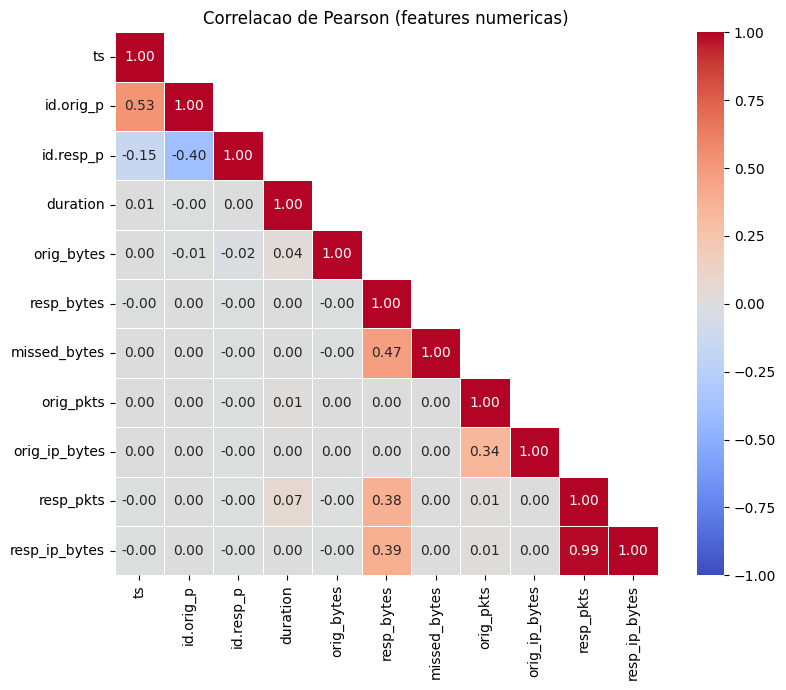

            a             b         r      |r|
resp_ip_bytes     resp_pkts  0.991981 0.991981
    id.orig_p            ts  0.526873 0.526873
 missed_bytes    resp_bytes  0.474666 0.474666
    id.resp_p     id.orig_p -0.395971 0.395971
resp_ip_bytes    resp_bytes  0.385791 0.385791
    resp_pkts    resp_bytes  0.382504 0.382504
orig_ip_bytes     orig_pkts  0.339971 0.339971
    id.resp_p            ts -0.148813 0.148813
    resp_pkts      duration  0.068332 0.068332
   orig_bytes      duration  0.035207 0.035207
   orig_bytes     id.resp_p -0.018614 0.018614
    orig_pkts      duration  0.009355 0.009355
    resp_pkts     orig_pkts  0.008278 0.008278
resp_ip_bytes     orig_pkts  0.008089 0.008089
     duration            ts  0.007708 0.007708
   orig_bytes     id.orig_p -0.006024 0.006024
orig_ip_bytes      duration  0.004778 0.004778
     duration     id.orig_p -0.004544 0.004544
resp_ip_bytes      duration  0.003711 0.003711
    resp_pkts orig_ip_bytes  0.003650 0.003650
resp_ip_bytes

In [9]:
cols_coerce = ["duration", "orig_bytes", "resp_bytes"]
partes = [df.select_dtypes(include=["number"]).copy()]
for c in cols_coerce:
    if c not in df.columns:
        continue
    s = df[c].astype(str).str.strip()
    s = s.replace({"-": np.nan, "(empty)": np.nan, "": np.nan})
    partes.append(pd.to_numeric(s, errors="coerce").rename(c))
num = pd.concat(partes, axis=1)
num = num.loc[:, ~num.columns.duplicated()]
num = num.dropna(axis=1, how="all")

corr = num.corr(method="pearson", min_periods=3)
print(corr.round(4).to_string())

n = len(corr.columns)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)
plt.figure(figsize=(max(9, 0.55 * n), max(7, 0.45 * n)))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    mask=mask,
    linewidths=0.5,
)
plt.title("Correlacao de Pearson (features numericas)")
plt.tight_layout()
plt.show()

cols_list = list(corr.columns)
pairs = []
for i in range(n):
    for j in range(i):
        r = corr.iloc[i, j]
        if pd.notna(r):
            pairs.append((cols_list[i], cols_list[j], r, abs(r)))
pairs.sort(key=lambda x: -x[3])
print(pd.DataFrame(pairs[:25], columns=["a", "b", "r", "|r|"]).to_string(index=False))


<div style="font-size: 30px; line-height: 1.25;">10) Feature Engineering</div>


### 5.1 `tam_medio_pacote` — Tamanho médio do pacote IP

**O que é:** razão entre o total de bytes IP trafegados e o total de pacotes da conexão.

$$\text{tam\_medio\_pacote} = \frac{\text{orig\_ip\_bytes} + \text{resp\_ip\_bytes}}{\text{orig\_pkts} + \text{resp\_pkts}}$$

**Motivação:** ataques como port scan e DDoS enviam muitos pacotes pequenos e uniformes — geralmente SYN sem payload. Tráfego legítimo tende a ter pacotes maiores e mais variados. Essa feature condensa esse comportamento em um único número por conexão.

**Caso especial:** quando não há pacotes registrados (`orig_pkts + resp_pkts = 0`), o resultado é `NaN` — evitamos divisão por zero e não imputamos um valor arbitrário.

### 5.2 `escopo_ips` — Escopo dos endereços IP da conexão

**O que é:** classificação do par de IPs (origem e destino) em quatro categorias, de acordo com se cada endereço é privado ou público.

| Código | Descrição |
|--------|-----------|
| `0` | Ambos públicos |
| `1` | Origem pública, destino privado |
| `2` | Origem privada, destino público *(padrão IoT infectado → C&C)* |
| `3` | Ambos privados |

**Motivação:** dispositivos IoT infectados (Mirai, Okiru) geralmente se comunicam com servidores de Comando & Controle na internet pública — padrão `escopo = 2`. Scans horizontais também partem de IPs privados em direção à internet. Codificar esse escopo permite ao modelo capturar o padrão sem precisar processar strings de IP diretamente.

**IPs privados (RFC 1918):** `10.0.0.0/8`, `172.16.0.0/12`, `192.168.0.0/16`.

A codificação usa operações de bit: bit 1 indica origem privada, bit 0 indica destino privado.

In [10]:
import ipaddress


def ip_e_privado(x):
    try:
        return ipaddress.ip_address(str(x).strip()).is_private
    except ValueError:
        return np.nan


tb = df["orig_pkts"].astype(np.float64) + df["resp_pkts"].astype(np.float64)
bb = df["orig_ip_bytes"].astype(np.float64) + df["resp_ip_bytes"].astype(np.float64)
df["tam_medio_pacote"] = np.where(tb > 0, bb / tb, np.nan)

priv_orig = df["id.orig_h"].map(ip_e_privado)
priv_resp = df["id.resp_h"].map(ip_e_privado)
valid = priv_orig.notna() & priv_resp.notna()
po = priv_orig[valid].to_numpy(dtype=bool)
pr = priv_resp[valid].to_numpy(dtype=bool)
codes = np.full(len(df), np.nan)
codes[valid.to_numpy()] = (po.astype(np.int8) << 1) | pr.astype(np.int8)
df["escopo_ips"] = codes

legenda = {
    0: "ambos_publicos",
    1: "orig_public_resp_privado",
    2: "orig_priv_resp_public",
    3: "ambos_privados",
}
print("escopo_ips:", legenda)
print(df["escopo_ips"].value_counts(dropna=False).sort_index().to_string())
print("tam_medio_pacote describe:")
print(df["tam_medio_pacote"].describe().to_string())


escopo_ips: {0: 'ambos_publicos', 1: 'orig_public_resp_privado', 2: 'orig_priv_resp_public', 3: 'ambos_privados'}
escopo_ips
0.0       60915
1.0       46098
2.0    16312449
3.0       38506
tam_medio_pacote describe:
count    1.626526e+07
mean     4.438427e+01
std      4.055039e+01
min      2.800000e+01
25%      4.000000e+01
50%      4.000000e+01
75%      4.000000e+01
max      6.327095e+03


<div style="font-size: 30px; line-height: 1.25;">11) Limpeza fina de IP</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Normaliza texto das colunas objeto, trata nan escrito como string, converte de novo métricas de fluxo para número, trata IPs inválidos removendo linhas se a taxa for baixa ou anulando e preenchendo caso contrário, recalcula tam_medio_pacote e escopo_ips e imputa NaN numéricos por mediana por label e global.</div>


In [11]:
import ipaddress

label_col = "label"
limite_pct_ips = 1.0

print(len(df), "linhas (antes)")


def ip_valid(x):
    if pd.isna(x):
        return False
    try:
        ipaddress.ip_address(str(x).strip())
        return True
    except ValueError:
        return False


def ip_e_privado(x):
    try:
        return ipaddress.ip_address(str(x).strip()).is_private
    except ValueError:
        return np.nan


for c in df.columns:
    if df[c].dtype != object and not pd.api.types.is_string_dtype(df[c]):
        continue
    s = df[c].astype(str).str.strip()
    s = s.mask(s.str.lower().eq("nan"), np.nan)
    s = s.replace({"-": np.nan, "(empty)": np.nan, "": np.nan})
    df[c] = s

for c in ["duration", "orig_bytes", "resp_bytes"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

vo = df["id.orig_h"].map(ip_valid)
vr = df["id.resp_h"].map(ip_valid)
invalid = ~(vo & vr)
n_inv = int(invalid.sum())
pct = 100.0 * n_inv / len(df) if len(df) else 0.0
print("IPs invalidos:", n_inv, f"({pct:.4f}%)")

if n_inv > 0:
    if pct <= limite_pct_ips:
        df = df.loc[~invalid].copy()
        print("Linhas removidas:", n_inv)
    else:
        df.loc[invalid, "id.orig_h"] = np.nan
        df.loc[invalid, "id.resp_h"] = np.nan
        print("IPs invalidos marcados como NaN.")

obj_cols2 = df.select_dtypes(include=["object"]).columns.tolist()
for col in obj_cols2:
    if not df[col].isna().any():
        continue
    if col in ("id.orig_h", "id.resp_h"):
        df[col] = df[col].fillna("missing")
        continue
    m = df[col].mode()
    if len(m):
        df[col] = df[col].fillna(m.iloc[0])
    df[col] = df[col].fillna("missing")

tb = df["orig_pkts"].astype(np.float64) + df["resp_pkts"].astype(np.float64)
bb = df["orig_ip_bytes"].astype(np.float64) + df["resp_ip_bytes"].astype(np.float64)
df["tam_medio_pacote"] = np.where(tb > 0, bb / tb, np.nan)

priv_orig = df["id.orig_h"].map(ip_e_privado)
priv_resp = df["id.resp_h"].map(ip_e_privado)
valid = priv_orig.notna() & priv_resp.notna()
po = priv_orig[valid].to_numpy(dtype=bool)
pr = priv_resp[valid].to_numpy(dtype=bool)
codes = np.full(len(df), np.nan)
codes[valid.to_numpy()] = (po.astype(np.int8) << 1) | pr.astype(np.int8)
df["escopo_ips"] = codes

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if not df[col].isna().any():
        continue
    med_cls = df.groupby(label_col, dropna=False)[col].transform("median")
    df[col] = df[col].fillna(med_cls)
    df[col] = df[col].fillna(df[col].median())

print(len(df), "linhas (depois)")
print("total NaN:", int(df.isna().sum().sum()))


16457968 linhas (antes)
IPs invalidos: 0 (0.0000%)


C:\Users\Diogo Marassi\AppData\Local\Temp\ipykernel_27496\565896816.py:54: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols2 = df.select_dtypes(include=["object"]).columns.tolist()


16457968 linhas (depois)
total NaN: 0


<div style="font-size: 30px; line-height: 1.25;">12) Outliers por IQR</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Marca outliers nas numéricas exceto label e escopo_ips com limites um vírgula cinco vezes o intervalo interquartil, resume contagens e percentagens por coluna, cruza com label, desenha barras do top dez colunas por percentagem de outliers e heatmap da taxa de outlier por label nessas colunas.</div>


Resumo de outliers por coluna (IQR):
                  outlier_count  outlier_pct  non_outlier_count
ts                      5458260      33.1648           10999708
duration                3137796      19.0655           13320172
tam_medio_pacote         940466       5.7144           15517502
orig_ip_bytes            729870       4.4348           15728098
orig_pkts                374714       2.2768           16083254
orig_bytes               162616       0.9881           16295352
resp_pkts                 70555       0.4287           16387413
resp_ip_bytes             70555       0.4287           16387413
resp_bytes                40700       0.2473           16417268
missed_bytes                133       0.0008           16457835
id.resp_p                     0       0.0000           16457968
id.orig_p                     0       0.0000           16457968

Taxa por classe dentro de cada coluna (%):
          coluna     label  sem_outlier  com_outlier
        duration    Benign       0

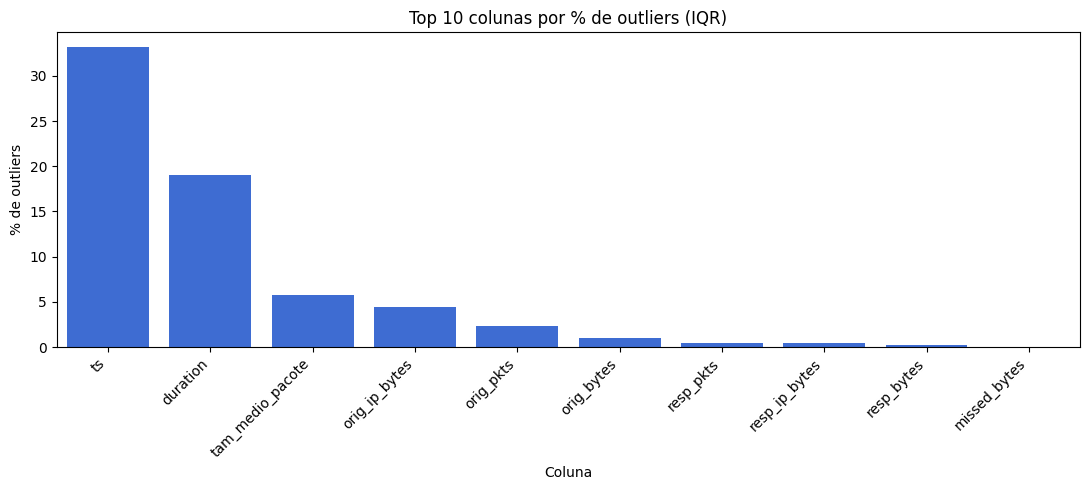

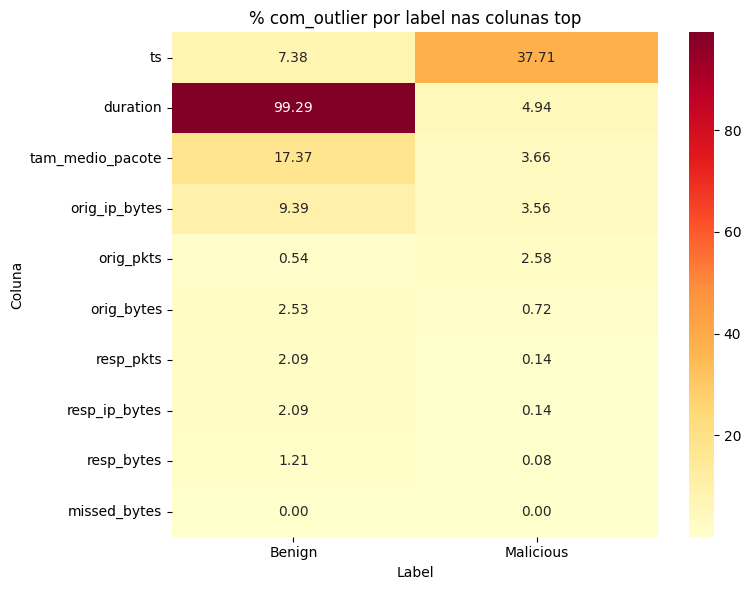

In [12]:
label_col = "label"

num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != label_col and c != "escopo_ips"
]

q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

mask_iqr = (df[num_cols].lt(lim_inf, axis=1) | df[num_cols].gt(lim_sup, axis=1))

outlier_count_por_col = mask_iqr.sum().astype(int)
outlier_rate_por_col = (mask_iqr.mean() * 100)

resumo_colunas = (
    pd.DataFrame(
        {
            "outlier_count": outlier_count_por_col,
            "outlier_pct": outlier_rate_por_col,
            "non_outlier_count": len(df) - outlier_count_por_col,
        }
    )
    .sort_values("outlier_pct", ascending=False)
)

print("Resumo de outliers por coluna (IQR):")
print(resumo_colunas.round(4).to_string())

if label_col in df.columns:
    frames = []
    for col in num_cols:
        t = pd.crosstab(df[label_col], mask_iqr[col], normalize="index") * 100
        t = t.rename(columns={False: "sem_outlier", True: "com_outlier"})
        t["coluna"] = col
        t = t.reset_index()
        if "sem_outlier" not in t.columns:
            t["sem_outlier"] = 0.0
        if "com_outlier" not in t.columns:
            t["com_outlier"] = 0.0
        frames.append(t[["coluna", label_col, "sem_outlier", "com_outlier"]])

    resumo_label_coluna = pd.concat(frames, ignore_index=True)
    resumo_label_coluna = resumo_label_coluna.sort_values(["coluna", label_col])

    print("\nTaxa por classe dentro de cada coluna (%):")
    print(resumo_label_coluna.round(4).to_string(index=False))


top_n = 10
plot_df = resumo_colunas.head(top_n).reset_index().rename(columns={"index": "coluna"})

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="coluna", y="outlier_pct", color="#2563eb")
plt.title(f"Top {top_n} colunas por % de outliers (IQR)")
plt.xlabel("Coluna")
plt.ylabel("% de outliers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

cols_top = plot_df["coluna"].tolist()
heat_df = resumo_label_coluna[resumo_label_coluna["coluna"].isin(cols_top)].copy()
heat_df = heat_df.pivot(index="coluna", columns=label_col, values="com_outlier").fillna(0)
heat_df = heat_df.reindex(cols_top)

plt.figure(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("% com_outlier por label nas colunas top")
plt.xlabel("Label")
plt.ylabel("Coluna")
plt.tight_layout()
plt.show()

<div style="font-size: 30px; line-height: 1.25;">13) Outliers em Malicious</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Restringe aos fluxos com label Malicious, cruza com a máscara de outliers para contar quantos têm pelo menos uma variável fora do IQR, mostra percentuais dentro só dessa classe e gráficos da proporção com e sem outlier e das colunas mais afetadas entre maliciosos.</div>


Total de linhas Malicious: 13993698
Malicious com >=1 outlier: 5603588 (40.0437%)
Malicious sem outlier: 8390110 (59.9563%)


C:\Users\Diogo Marassi\AppData\Local\Temp\ipykernel_27496\1983655583.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_mal, x="categoria", y="percentual", palette=["#dc2626", "#16a34a"])


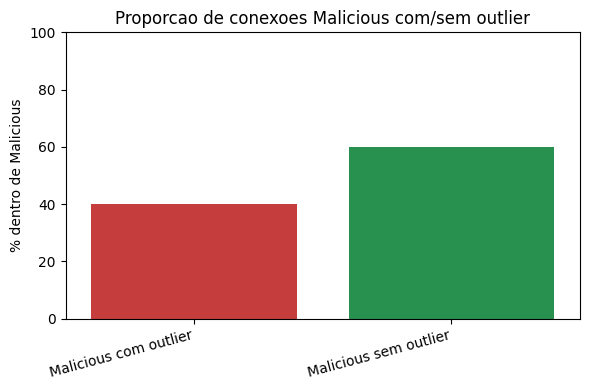

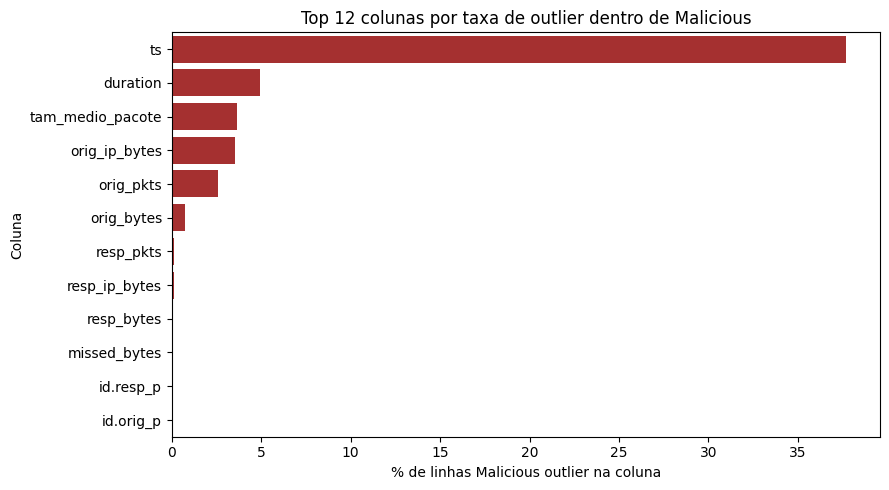


Top colunas por % de outlier dentro de Malicious:
          coluna  outlier_pct_malicious
              ts                37.7058
        duration                 4.9385
tam_medio_pacote                 3.6625
   orig_ip_bytes                 3.5620
       orig_pkts                 2.5818
      orig_bytes                 0.7170
       resp_pkts                 0.1362
   resp_ip_bytes                 0.1362
      resp_bytes                 0.0786
    missed_bytes                 0.0007
       id.resp_p                 0.0000
       id.orig_p                 0.0000


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

label_alvo = "Malicious"
mal_mask = df[label_col].astype(str).eq(label_alvo)

mal_total = int(mal_mask.sum())
if mal_total == 0:
    print(f"Nenhuma linha com label={label_alvo} encontrada.")
else:
    mal_any_outlier = mask_iqr.loc[mal_mask].any(axis=1)
    mal_outliers = int(mal_any_outlier.sum())
    mal_nao_outliers = mal_total - mal_outliers
    mal_outlier_pct = (mal_outliers / mal_total) * 100

    print(f"Total de linhas {label_alvo}: {mal_total}")
    print(f"{label_alvo} com >=1 outlier: {mal_outliers} ({mal_outlier_pct:.4f}%)")
    print(f"{label_alvo} sem outlier: {mal_nao_outliers} ({100 - mal_outlier_pct:.4f}%)")

    resumo_mal = pd.DataFrame(
        {
            "categoria": [f"{label_alvo} com outlier", f"{label_alvo} sem outlier"],
            "percentual": [mal_outlier_pct, 100 - mal_outlier_pct],
        }
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=resumo_mal, x="categoria", y="percentual", palette=["#dc2626", "#16a34a"])
    plt.ylim(0, 100)
    plt.ylabel("% dentro de Malicious")
    plt.xlabel("")
    plt.title("Proporcao de conexoes Malicious com/sem outlier")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

    mal_por_col = (mask_iqr.loc[mal_mask].mean() * 100).sort_values(ascending=False)
    top_n = 12
    mal_por_col_top = mal_por_col.head(top_n).reset_index()
    mal_por_col_top.columns = ["coluna", "outlier_pct_malicious"]

    plt.figure(figsize=(9, 5))
    sns.barplot(data=mal_por_col_top, x="outlier_pct_malicious", y="coluna", color="#b91c1c")
    plt.xlabel("% de linhas Malicious outlier na coluna")
    plt.ylabel("Coluna")
    plt.title(f"Top {top_n} colunas por taxa de outlier dentro de Malicious")
    plt.tight_layout()
    plt.show()

    print("\nTop colunas por % de outlier dentro de Malicious:")
    print(mal_por_col_top.round(4).to_string(index=False))

In [14]:
print(DATASET_PATH if "DATASET_PATH" in globals() else "sem DATASET_PATH")
print(df.shape)
print(df.columns.tolist()[:20], "... total:", len(df.columns))
print("ts" in df.columns)

..\dataset_balanceado.csv
(16457968, 22)
['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'detailed-label', 'scenario'] ... total: 22
True


<div style="font-size: 30px; line-height: 1.25;">14) Tempo e dia ou noite</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Converte ts para datetime tentando epoch em segundos e depois parse livre, cria ts_dia valendo um entre seis e dezoito horas e zero fora desse intervalo e mostra um recorte com ts e ts_dia para conferência.</div>


In [15]:
candidatas_ts = ["ts", "timestamp", "time", "datetime", "date"]
col_ts = next((c for c in candidatas_ts if c in df.columns), None)

if col_ts is None:
    raise KeyError(f"Nenhuma coluna de timestamp encontrada. Colunas disponíveis: {df.columns.tolist()}")

ts_dt = pd.to_datetime(df[col_ts], errors="coerce", unit="s")
ts_dt_fallback = pd.to_datetime(df.loc[ts_dt.isna(), col_ts], errors="coerce")
ts_dt.loc[ts_dt.isna()] = ts_dt_fallback

df["ts_dia"] = ((ts_dt.dt.hour >= 6) & (ts_dt.dt.hour < 18)).fillna(False).astype("int8")
df[[col_ts, "ts_dia"]].head()

,ts,ts_dia
0,1.540469e+09,1
1,1.540469e+09,1
2,1.540469e+09,1
3,1.540470e+09,1
4,1.540470e+09,1


<div style="font-size: 30px; line-height: 1.25;">15) Escalonamento robusto</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Aplica RobustScaler do scikit-learn a todas as numéricas exceto label e escopo_ips, substituindo valores no DataFrame por versões baseadas em mediana e amplitude interquartil para reduzir influência de extremos, e imprime a lista de colunas escaladas.</div>


In [16]:
from sklearn.preprocessing import RobustScaler

label_col = "label"
nao_escalar = {"escopo_ips"}

cols_escalar = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c != label_col and c not in nao_escalar
]

print(f'Colunas que nao serao escaladas: {cols_escalar}')

scaler_rt = RobustScaler()
df[cols_escalar] = scaler_rt.fit_transform(df[cols_escalar].astype(np.float64))

print("RobustScaler aplicado a:", cols_escalar)


Colunas que nao serao escaladas: ['ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tam_medio_pacote', 'ts_dia']
RobustScaler aplicado a: ['ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tam_medio_pacote', 'ts_dia']


<div style="font-size: 30px; line-height: 1.25;">16) Conferência pós-escala</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Imprime dimensão e dtypes, lista colunas que passaram pelo RobustScaler, describe dessas colunas, dez primeiras linhas com escaladas mais escopo_ips e label quando existem e contagem de NaN por coluna escalada.</div>


In [17]:
label_col = "label"
nao_escalar = {"escopo_ips"}
cols_escalar = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c != label_col and c not in nao_escalar
]

print("Dimensao:", len(df), "linhas,", df.shape[1], "colunas")
print("\nDtypes")
print(df.dtypes.to_string())

print("\nColunas com RobustScaler:")
print(cols_escalar)

print("\ndescribe() — colunas escaladas")
print(df[cols_escalar].describe().T.to_string())

extras = [c for c in ("escopo_ips", "label") if c in df.columns]
print("\nPrimeiras 10 linhas (escaladas +", extras, ")")
print(df[cols_escalar + extras].head(10).to_string())

print("\nNaN por coluna (escaladas)")
print(df[cols_escalar].isna().sum().to_string())


Dimensao: 16457968 linhas, 23 colunas

Dtypes
ts                  float64
uid                     str
id.orig_h               str
id.orig_p           float64
id.resp_h               str
id.resp_p           float64
proto                   str
duration            float64
orig_bytes          float64
resp_bytes          float64
conn_state              str
missed_bytes        float64
history                 str
orig_pkts           float64
orig_ip_bytes       float64
resp_pkts           float64
resp_ip_bytes       float64
label                   str
detailed-label          str
scenario                str
tam_medio_pacote    float64
escopo_ips          float64
ts_dia              float64

Colunas com RobustScaler:
['ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tam_medio_pacote', 'ts_dia']

describe() — colunas escaladas
                       count          mean           std        min     

<div style="font-size: 30px; line-height: 1.25;">17) Correlação final</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Recalcula Pearson entre todas as numéricas incluindo tam_medio_pacote e escopo_ips, pode imprimir submatriz dessas features com o resto, desenha heatmap triangular completo e lista pares envolvendo as novas features ordenados por valor absoluto da correlação.</div>


Correlacao das features novas com todas as numericas:
                  tam_medio_pacote  escopo_ips
ts                         -0.1768      0.1148
id.orig_p                  -0.0144      0.0561
id.resp_p                  -0.0850      0.0468
duration                    0.0128     -0.0013
orig_bytes                  0.0030      0.0012
resp_bytes                  0.0024      0.0000
missed_bytes                0.0000      0.0000
orig_pkts                   0.0008      0.0000
orig_ip_bytes               0.0090     -0.0000
resp_pkts                   0.0065      0.0004
resp_ip_bytes               0.0062      0.0000
tam_medio_pacote            1.0000     -0.6688
escopo_ips                 -0.6688      1.0000
ts_dia                      0.0722     -0.0928


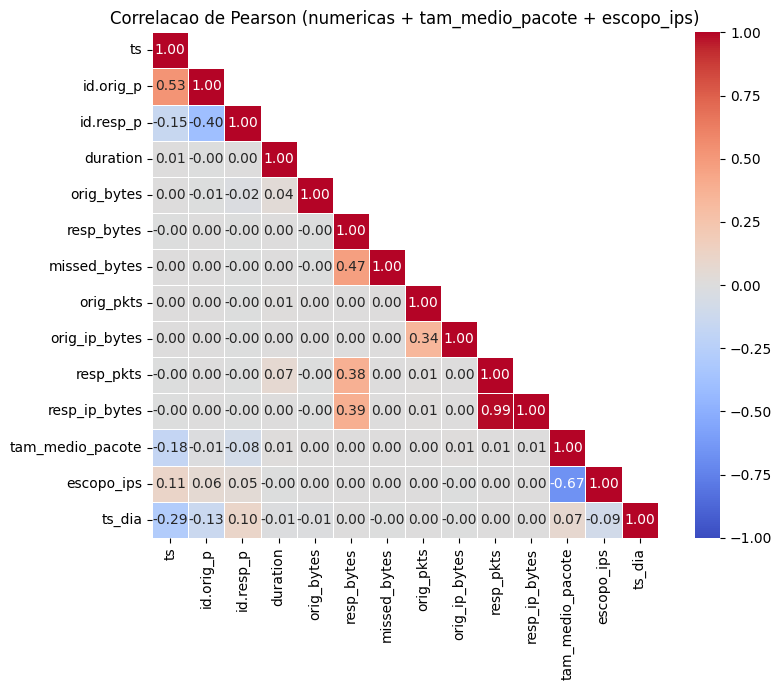


Pares envolvendo tam_medio_pacote ou escopo_ips (|r| decrescente):
               a                b         r      |r|
      escopo_ips tam_medio_pacote -0.668804 0.668804
tam_medio_pacote               ts -0.176758 0.176758
      escopo_ips               ts  0.114810 0.114810
          ts_dia       escopo_ips -0.092785 0.092785
tam_medio_pacote        id.resp_p -0.084976 0.084976
          ts_dia tam_medio_pacote  0.072180 0.072180
      escopo_ips        id.orig_p  0.056130 0.056130
      escopo_ips        id.resp_p  0.046795 0.046795
tam_medio_pacote        id.orig_p -0.014397 0.014397
tam_medio_pacote         duration  0.012777 0.012777
tam_medio_pacote    orig_ip_bytes  0.009008 0.009008
tam_medio_pacote        resp_pkts  0.006539 0.006539
tam_medio_pacote    resp_ip_bytes  0.006232 0.006232
tam_medio_pacote       orig_bytes  0.003009 0.003009
tam_medio_pacote       resp_bytes  0.002386 0.002386
      escopo_ips         duration -0.001299 0.001299
      escopo_ips       orig_byt

In [18]:
num_corr = df.select_dtypes(include=[np.number]).copy()
corr2 = num_corr.corr(method="pearson", min_periods=3)

subcols = [c for c in ("tam_medio_pacote", "escopo_ips") if c in corr2.columns]
if subcols:
    print("Correlacao das features novas com todas as numericas:")
    print(corr2[subcols].round(4).to_string())

n = len(corr2.columns)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)
plt.figure(figsize=(max(9, 0.55 * n), max(7, 0.45 * n)))
sns.heatmap(
    corr2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    mask=mask,
    linewidths=0.5,
)
plt.title("Correlacao de Pearson (numericas + tam_medio_pacote + escopo_ips)")
plt.tight_layout()
plt.show()

cols_list = list(corr2.columns)
pairs = []
for i in range(n):
    for j in range(i):
        r = corr2.iloc[i, j]
        if pd.notna(r):
            pairs.append((cols_list[i], cols_list[j], r, abs(r)))
pairs.sort(key=lambda x: -x[3])
novas = {"tam_medio_pacote", "escopo_ips"}
pares_novas = [p for p in pairs if p[0] in novas or p[1] in novas]
print("\nPares envolvendo tam_medio_pacote ou escopo_ips (|r| decrescente):")
print(pd.DataFrame(pares_novas[:25], columns=["a", "b", "r", "|r|"]).to_string(index=False))


In [19]:
print(DATASET_PATH if "DATASET_PATH" in globals() else "sem DATASET_PATH")
print(df.shape)
print(df.columns.tolist()[:20], "... total:", len(df.columns))
print("ts" in df.columns)

..\dataset_balanceado.csv
(16457968, 23)
['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'detailed-label', 'scenario'] ... total: 23
True


<div style="font-size: 30px; line-height: 1.25;">18) Analise de desbalanceamento</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Calcula a distribuicao da coluna label com contagens e percentuais, mede a razao entre classe majoritaria e minoritaria para quantificar desbalanceamento, plota barras com anotacoes de percentual e sugere pesos por classe no formato class_weight balanced.</div>

Distribuicao de classes (label):
           quantidade  percentual
label                            
Malicious    13993698     85.0269
Benign        2464270     14.9731

Metricas de desbalanceamento:
Classe majoritaria: Malicious (13,993,698 amostras)
Classe minoritaria: Benign (2,464,270 amostras)
Razao majoritaria/minoritaria: 5.68x


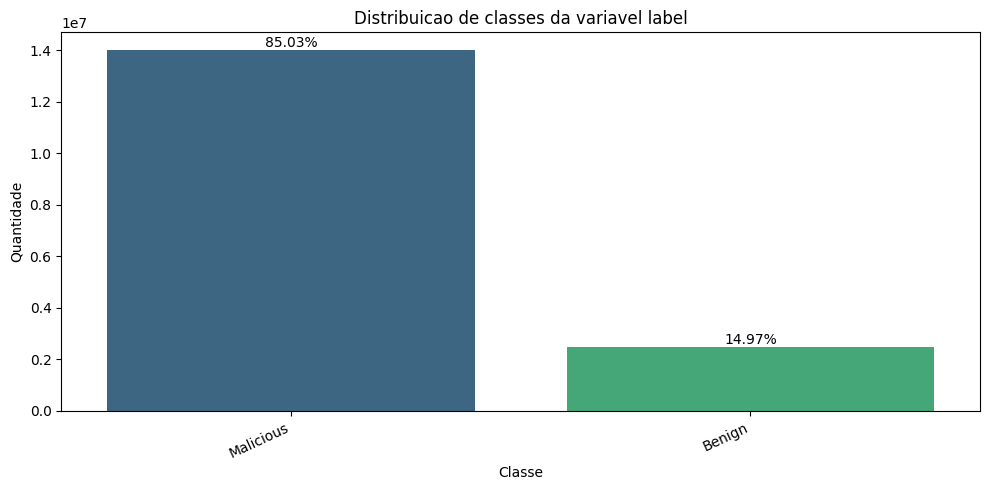


Pesos balanceados sugeridos por classe (estilo class_weight='balanced'):
Malicious: 0.588049
Benign: 3.339319


In [20]:
label_col = "label"

if label_col not in df.columns:
    raise KeyError(f"Coluna alvo '{label_col}' nao encontrada no DataFrame.")

s = (
    df[label_col]
    .astype(str)
    .str.strip()
    .replace({"": "(vazio)", "nan": "(vazio)", "None": "(vazio)"})
)

contagens = s.value_counts(dropna=False)
proporcoes = (contagens / contagens.sum() * 100).round(4)
resumo = pd.DataFrame({
    "quantidade": contagens,
    "percentual": proporcoes,
})

print("Distribuicao de classes (label):")
print(resumo.to_string())

if len(contagens) > 1:
    classe_maior = contagens.idxmax()
    classe_menor = contagens.idxmin()
    razao_desbalanceamento = contagens.max() / contagens.min()

    print("\nMetricas de desbalanceamento:")
    print(f"Classe majoritaria: {classe_maior} ({contagens.max():,} amostras)")
    print(f"Classe minoritaria: {classe_menor} ({contagens.min():,} amostras)")
    print(f"Razao majoritaria/minoritaria: {razao_desbalanceamento:.2f}x")
else:
    print("\nApenas uma classe encontrada; nao ha desbalanceamento entre classes para medir.")

plt.figure(figsize=(10, 5))
ordem = contagens.index.tolist()
ax = sns.barplot(
    x=contagens.index,
    y=contagens.values,
    order=ordem,
    palette="viridis",
    hue=contagens.index,
    legend=False,
)
ax.set_title("Distribuicao de classes da variavel label")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=25, ha="right")

for i, v in enumerate(contagens.values):
    ax.text(i, v, f"{(v / contagens.sum()) * 100:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

if len(contagens) > 1:
    pesos_balanceados = {c: len(s) / (len(contagens) * n) for c, n in contagens.items()}
    print("\nPesos balanceados sugeridos por classe (estilo class_weight='balanced'):")
    for c, w in pesos_balanceados.items():
        print(f"{c}: {w:.6f}")

<div style="font-size: 30px; line-height: 1.25;">19) Entendimentos das colunas categóricas</div>

  - proto — Protocolo de transporte (3 valores: tcp, udp, icmp)
    - One-Hot Encoding: cria 3 colunas binárias, uma por protocolo. Ideal aqui — baixa cardinalidade e sem ordem entre
  os valores
    - Label Encoding: substitui por inteiro (0, 1, 2). Simples, mas implica uma ordem artificial que não existe entre
  protocolos

  ---
  - conn_state — Estado final da conexão (13 valores: S0, SF, REJ, etc.)
    - One-Hot Encoding: cria 13 colunas binárias. Adequado — cardinalidade razoável e sem ordem natural entre os estados
    - Label Encoding: possível, mas os estados não têm relação ordinal entre si
    - Ordinal Encoding: poderia fazer sentido com uma ordem manual definida (ex: conexão completa > sem resposta >
  rejeitada), mas é subjetivo e difícil de justificar

  ---
  - history — Sequência de eventos da conexão (89–325 valores distintos: S, Dd, ShAFf, etc.)
    - One-Hot Encoding: possível, mas criaria muitas colunas esparsas dado a alta cardinalidade
    - Frequency Encoding: substitui cada valor pela sua frequência no dataset. Compacto e captura raridade
    - Target Encoding: substitui cada valor pela proporção de Malicious naquele grupo. Poderoso, mas exige cuidado para
  não vazar o target durante o treino
    - Remoção: candidata à eliminação, pois conn_state já captura parte dessa informação de forma mais estruturada

  ---
  - id.orig_h — IP de origem (32k+ valores distintos)
    - Remoção: alta cardinalidade extrema; tende a causar overfitting e não generaliza para IPs novos
    - Extração de features: já foi parcialmente feito com escopo_ips (privado/público). Poderia-se extrair mais, como o
  prefixo /24 da rede
    - Target Encoding: substituir pelo percentual histórico de Malicious por IP. Arriscado — IPs novos não têm histórico
    - Frequency Encoding: substituir pela contagem de ocorrências do IP

  ---
  - id.resp_h — IP de destino (15M+ valores distintos)
    - Remoção: cardinalidade absurdamente alta — quase um identificador único por linha. Praticamente inviável qualquer
  encoding direto
    - Extração de features: similar ao id.orig_h; a informação útil já foi capturada em escopo_ips

  ---
  - detailed-label — Tipo específico de ataque (PortScan, DDoS, Okiru, unknown, etc.)
    - Remoção: é uma decomposição da variável alvo (label) — usá-la como feature causaria data leakage (o modelo
  aprenderia a partir de informação que não existe em produção)
    - Uso como segundo target: pode servir como variável alvo de uma classificação multiclasse separada, mas não como
  feature

  ---
  - scenario — Identificador do cenário de captura (22 valores: CTU-IoT-Malware-Capture-X, etc.)
    - Remoção: é um metadado do dataset, não uma feature de rede real. Usá-lo causaria overfitting ao conjunto de treino
   e não generalizaria para capturas novas
    - One-Hot Encoding: tecnicamente possível, mas não recomendado pelo motivo acima
    - Target Encoding: idem

  ---
  - label — Variável alvo (2 valores: Benign, Malicious)
    - Binary Encoding: Benign = 0, Malicious = 1. Direto e necessário para qualquer modelo — não entra no scaler

### Verificação empirica

In [21]:
df.head(5)

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,duration,orig_bytes,resp_bytes,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed-label,scenario,tam_medio_pacote,escopo_ips,ts_dia
0,-3.665003,CGm6jB4dXK71ZDWUDh,192.168.1.132,0.659258,216.239.35.4,-0.213944,udp,57091.0,48.0,48.0,...,0.0,0.90,1.0,76.0,Benign,PartOfAHorizontalPortScan,CTU-Honeypot-Capture-4-1,36.0,2.0,1.0
1,-3.665062,CnaDAG3n5r8eiG4su2,192.168.1.132,-1.183399,239.255.255.250,-0.166165,udp,80183788.5,7536.0,0.0,...,23.0,204.20,0.0,0.0,Benign,PartOfAHorizontalPortScan,CTU-Honeypot-Capture-4-1,302.0,2.0,1.0
2,-3.664957,CUrxU238nt0m6yTgKf,192.168.1.132,-0.177721,216.239.35.8,-0.213944,udp,8492.0,48.0,48.0,...,0.0,0.90,1.0,76.0,Benign,PartOfAHorizontalPortScan,CTU-Honeypot-Capture-4-1,36.0,2.0,1.0
3,-3.664710,CGQf8t1kjdxB5PHXL4,192.168.1.132,0.487540,2.16.60.82,-0.205340,tcp,1747.5,0.0,0.0,...,4.0,4.30,3.0,144.0,Benign,PartOfAHorizontalPortScan,CTU-Honeypot-Capture-4-1,4.5,2.0,1.0
4,-3.664710,CUo9DH2QDnCaBIGjkg,192.168.1.132,0.468265,192.168.1.1,-0.215826,udp,18361.0,34.0,311.0,...,0.0,0.55,1.0,339.0,Benign,PartOfAHorizontalPortScan,CTU-Honeypot-Capture-4-1,160.5,3.0,1.0


In [22]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
ts,-3.665003,-3.665062,-3.664957,-3.66471,-3.66471,-3.664939,-3.664571,-3.664512,-3.664419,-3.664383
uid,CGm6jB4dXK71ZDWUDh,CnaDAG3n5r8eiG4su2,CUrxU238nt0m6yTgKf,CGQf8t1kjdxB5PHXL4,CUo9DH2QDnCaBIGjkg,CAvXOZ3htimWEtglii,CfJsUD2NGQvnK2p7Vd,CVwKZS98dRvk1jeH2,CzbHG4aoHRooWvyMg,CbTB0B2ZnnDWLAIml3
id.orig_h,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132,192.168.1.132
id.orig_p,0.659258,-1.183399,-0.177721,0.48754,0.468265,-1.183399,0.640989,-0.099195,0.249659,0.222597
id.resp_h,216.239.35.4,239.255.255.250,216.239.35.8,2.16.60.82,192.168.1.1,239.255.255.250,216.239.35.12,216.239.35.0,216.239.35.4,216.239.35.8
id.resp_p,-0.213944,-0.166165,-0.213944,-0.20534,-0.215826,-0.166165,-0.213944,-0.213944,-0.213944,-0.213944
proto,udp,udp,udp,tcp,udp,udp,udp,udp,udp,udp
duration,57091.0,80183788.5,8492.0,1747.5,18361.0,192259129.5,135165.0,55713.5,57215.5,8491.0
orig_bytes,48.0,7536.0,48.0,0.0,34.0,15072.0,48.0,48.0,48.0,48.0
resp_bytes,48.0,0.0,48.0,0.0,311.0,0.0,48.0,48.0,48.0,48.0


## Distribuicao de detailed label

Distribuição de detailed-label:
                                  quantidade  percentual
detailed-label                                          
PartOfAHorizontalPortScan           10917126       66.33
Okiru                                4018292       24.42
DDoS                                 1455640        8.84
C&C-HeartBeat                          33673        0.20
C&C                                    21995        0.13
Attack                                  9398        0.06
C&C-PartOfAHorizontalPortScan            888        0.01
C&C-HeartBeat-Attack                     834        0.01
C&C-FileDownload                          53        0.00
C&C-Torii                                 30        0.00
FileDownload                              18        0.00
C&C-HeartBeat-FileDownload                11        0.00
PartOfAHorizontalPortScan-Attack           5        0.00
Okiru-Attack                               3        0.00
C&C-Mirai                                  2        0.00

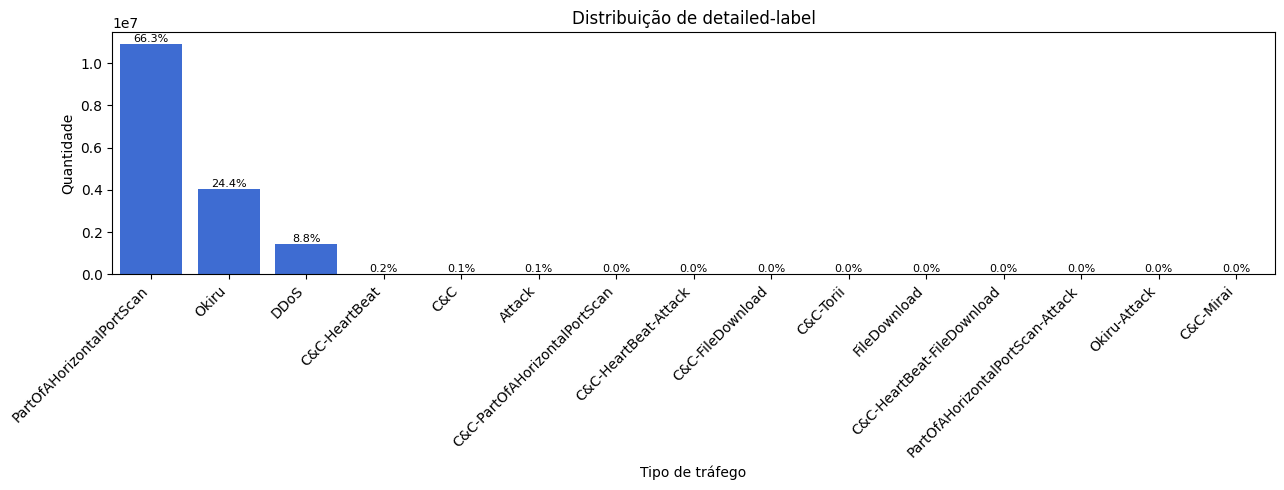

In [23]:
dl = df["detailed-label"].value_counts()
dl_pct = (dl / len(df) * 100).round(2)
resumo_dl = pd.DataFrame({"quantidade": dl, "percentual": dl_pct})
print("Distribuição de detailed-label:")
print(resumo_dl.to_string())

plt.figure(figsize=(13, 5))
ax = sns.barplot(x=dl.index, y=dl.values, color="#2563eb")
ax.set_title("Distribuição de detailed-label")
ax.set_xlabel("Tipo de tráfego")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
for i, (v, p) in enumerate(zip(dl.values, dl_pct.values)):
    ax.text(i, v, f"{p:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

### Agrupamento de `detailed-label` para treino

  Os 15 rótulos originais foram consolidados em **3 grupos** com base na fase do ciclo de vida do malware IoT (botnets
  Mirai e variantes), equilibrando semântica e viabilidade de treino.

  **Distribuição resultante (aproximada):**

  | Grupo | Amostras | % |
  |-------|----------|---|
  | Scan | 10.918.019 | 66,3% |
  | Botnet_CC | 4.084.309 | 24,8% |
  | DDoS | 1.455.640 | 8,8% |

  O desbalanceamento entre as três classes ainda é relevante e deve ser tratado no treino com `class_weight='balanced'`
  ou técnicas de oversampling/undersampling.

NaN após mapeamento: 0

Distribuição após agrupamento:
                quantidade  percentual
detailed-label                        
Scan              10918019       66.34
Botnet_CC          4084309       24.82
DDoS               1455640        8.84


C:\Users\Diogo Marassi\AppData\Local\Temp\ipykernel_27496\1318819597.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dl.index, y=dl.values, palette=["#2563eb", "#16a34a", "#dc2626"])


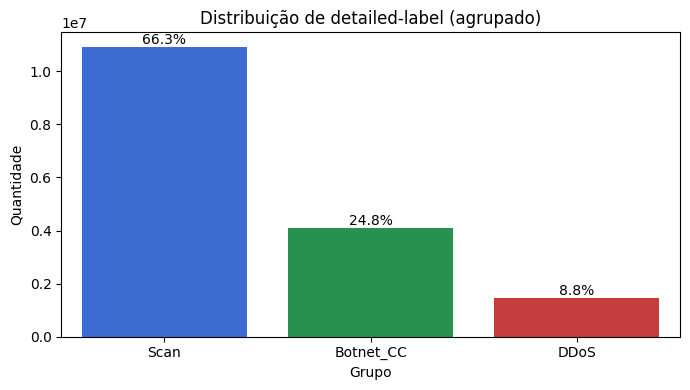

In [24]:
mapa_grupos = {
    # Scan — propagação: dispositivo varrendo a rede buscando novos alvos
    "PartOfAHorizontalPortScan":          "Scan",
    "C&C-PartOfAHorizontalPortScan":      "Scan",
    "PartOfAHorizontalPortScan-Attack":   "Scan",

    # DDoS — ataque volumétrico coordenado
    "DDoS":                               "DDoS",

    # Botnet_CC — tudo o mais: comunicação C&C, heartbeats,
    # botnets específicos (Okiru, Torii, Mirai) e comportamentos
    # de ataque/download demasiado raros para classe própria
    "Okiru":                              "Botnet_CC",
    "Okiru-Attack":                       "Botnet_CC",
    "C&C":                                "Botnet_CC",
    "C&C-HeartBeat":                      "Botnet_CC",
    "C&C-HeartBeat-Attack":               "Botnet_CC",
    "C&C-Torii":                          "Botnet_CC",
    "C&C-Mirai":                          "Botnet_CC",
    "Attack":                             "Botnet_CC",
    "FileDownload":                       "Botnet_CC",
    "C&C-FileDownload":                   "Botnet_CC",
    "C&C-HeartBeat-FileDownload":         "Botnet_CC",
}

df["detailed-label"] = df["detailed-label"].map(mapa_grupos)

print("NaN após mapeamento:", df["detailed-label"].isna().sum())

dl = df["detailed-label"].value_counts()
dl_pct = (dl / len(df) * 100).round(2)
resumo_dl = pd.DataFrame({"quantidade": dl, "percentual": dl_pct})
print("\nDistribuição após agrupamento:")
print(resumo_dl.to_string())

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=dl.index, y=dl.values, palette=["#2563eb", "#16a34a", "#dc2626"])
ax.set_title("Distribuição de detailed-label (agrupado)")
ax.set_xlabel("Grupo")
ax.set_ylabel("Quantidade")
for i, (v, p) in enumerate(zip(dl.values, dl_pct.values)):
    ax.text(i, v, f"{p:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### Truncagem dos maliciosos por grupo de `detailed-label`

  O dataset apresenta dois níveis de desbalanceamento:

  1. **Binário:** Malicious (~85%) vs Benign (~15%)
  2. **Multiclasse:** Scan (66%) >> Botnet_CC (25%) >> DDoS (9%)

  A estratégia adota o **DDoS como referência** — por ser o menor grupo entre os maliciosos — e trunca aleatoriamente
  Scan e Botnet_CC até esse valor. Todos os registros benignos são mantidos intactos.

  **Resultado esperado:**
  | Grupo | Antes | Depois |
  |-------|-------|--------|
  | Scan | ~10,9M | ~1,46M |
  | Botnet_CC | ~4,1M | ~1,46M |
  | DDoS | ~1,46M | ~1,46M |
  | **Total malicioso** | ~13,9M | ~4,37M |
  | **Benign** | 2,46M | 2,46M (inalterado) |
  | **Razão Mal/Ben** | ~5,7x | ~1,8x |

  A razão de desbalanceamento cai de ~5,7x para ~1,8x — significativamente mais tratável para modelos de classificação.

In [25]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Índices dos benignos — todos mantidos
benignos_idx = df.index[df["label"] == "Benign"].to_numpy()

# Amostra de índices por grupo maligno
mal_mask = df["label"] == "Malicious"
target_n = int(df.loc[mal_mask, "detailed-label"].value_counts().min())
print(f"Target por grupo (mínimo = DDoS): {target_n:,}")

mal_idx_list = []
for grupo in df.loc[mal_mask, "detailed-label"].unique():
    grupo_idx = df.index[mal_mask & (df["detailed-label"] == grupo)].to_numpy()
    sampled = rng.choice(grupo_idx, size=target_n, replace=False)
    mal_idx_list.append(sampled)

keep_idx = np.concatenate([benignos_idx] + mal_idx_list)

# Máscara booleana — evita fancy indexing com índices não ordenados
bool_mask = np.zeros(len(df), dtype=bool)
bool_mask[keep_idx] = True

df = df.loc[bool_mask]
df.reset_index(drop=True, inplace=True)

print(f"\nDimensão após truncagem: {df.shape}")

lbl = df["label"].value_counts()
lbl_pct = (lbl / len(df) * 100).round(2)
print("\nDesbalanceamento Benign vs Malicious:")
print(pd.DataFrame({"quantidade": lbl, "percentual": lbl_pct}).to_string())
print(f"\nRazão Malicious/Benign: {lbl['Malicious'] / lbl['Benign']:.2f}x")

dl_mal = df[df["label"] == "Malicious"]["detailed-label"].value_counts()
dl_mal_pct = (dl_mal / len(df) * 100).round(2)
print("\nDistribuição de detailed-label (maliciosos após truncagem):")
print(pd.DataFrame({"quantidade": dl_mal, "percentual": dl_mal_pct}).to_string())

Target por grupo (mínimo = DDoS): 1,455,640

Dimensão após truncagem: (6831190, 23)

Desbalanceamento Benign vs Malicious:
           quantidade  percentual
label                            
Malicious     4366920       63.93
Benign        2464270       36.07

Razão Malicious/Benign: 1.77x

Distribuição de detailed-label (maliciosos após truncagem):
                quantidade  percentual
detailed-label                        
Botnet_CC          1455640       21.31
Scan               1455640       21.31
DDoS               1455640       21.31


<div style="font-size: 30px; line-height: 1.25;">20) Encoding das colunas categóricas</div>
<div style="font-size: 17px; line-height: 1.55; margin-top: 12px;">Transforma as colunas categóricas em representações numéricas adequadas para modelos de machine learning: remove colunas sem valor preditivo ou que causariam data leakage, aplica One-Hot Encoding em proto e conn_state, Frequency Encoding em history, e Binary Encoding no target label.</div>

### 20.1 Remoção de colunas sem valor preditivo

Remove `uid`, `id.orig_h`, `id.resp_h`, `scenario`:

- **`uid`** — identificador único de conexão, sem padrão aprendível
- **`id.orig_h`** — IP de origem com 32k+ valores; a informação útil (privado/público) já foi capturada em `escopo_ips`
- **`id.resp_h`** — quase único por linha (15M+ valores distintos), inviável como feature
- **`scenario`** — metadado do dataset, não feature de rede real; causaria overfitting ao conjunto de treino

In [26]:
remover_enc = ["uid", "id.orig_h", "id.resp_h", "scenario"]
remover_enc = [c for c in remover_enc if c in df.columns]
df = df.drop(columns=remover_enc)

print("Colunas removidas:", remover_enc)
print("Dimensão:", df.shape)
print("Colunas restantes:", df.columns.tolist())

Colunas removidas: ['uid', 'id.orig_h', 'id.resp_h', 'scenario']
Dimensão: (6831190, 19)
Colunas restantes: ['ts', 'id.orig_p', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'detailed-label', 'tam_medio_pacote', 'escopo_ips', 'ts_dia']


### 20.2 `proto` — One-Hot Encoding

Baixa cardinalidade (3 valores: `tcp`, `udp`, `icmp`) e sem ordem natural entre os protocolos. OHE cria 3 colunas binárias independentes, uma por protocolo, sem introduzir relação ordinal artificial.

In [27]:
proto_dummies = pd.get_dummies(df["proto"], prefix="proto", dtype=np.float64)
df = pd.concat([df.drop(columns=["proto"]), proto_dummies], axis=1)

print("Colunas proto geradas:", proto_dummies.columns.tolist())
print("\nContagem de 1s por coluna (verificação):")
print(proto_dummies.sum().astype(int).to_string())

Colunas proto geradas: ['proto_icmp', 'proto_tcp', 'proto_udp']

Contagem de 1s por coluna (verificação):
proto_icmp      32958
proto_tcp     6548459
proto_udp      249773


### 20.3 `conn_state` — One-Hot Encoding

13 valores distintos (`S0`, `SF`, `REJ`, `RSTO`, etc.) sem relação ordinal entre si. OHE cria 13 colunas binárias independentes — cardinalidade razoável e cada estado representa uma categoria distinta do resultado final da conexão.

In [28]:
conn_dummies = pd.get_dummies(df["conn_state"], prefix="conn_state", dtype=np.float64)
df = pd.concat([df.drop(columns=["conn_state"]), conn_dummies], axis=1)

print("Colunas conn_state geradas:", conn_dummies.columns.tolist())
print("\nContagem de 1s por coluna (verificação):")
print(conn_dummies.sum().astype(int).to_string())

Colunas conn_state geradas: ['conn_state_OTH', 'conn_state_REJ', 'conn_state_RSTO', 'conn_state_RSTOS0', 'conn_state_RSTR', 'conn_state_RSTRH', 'conn_state_S0', 'conn_state_S1', 'conn_state_S2', 'conn_state_S3', 'conn_state_SF', 'conn_state_SH', 'conn_state_SHR']

Contagem de 1s por coluna (verificação):
conn_state_OTH        233569
conn_state_REJ         20009
conn_state_RSTO         2690
conn_state_RSTOS0     259602
conn_state_RSTR          552
conn_state_RSTRH        1274
conn_state_S0        6279702
conn_state_S1            121
conn_state_S2            157
conn_state_S3           1477
conn_state_SF          31811
conn_state_SH            203
conn_state_SHR            23


### 20.4 `history` — Frequency Encoding

Alta cardinalidade (325 valores distintos: `S`, `Dd`, `ShAFf`, etc.). Frequency Encoding substitui cada padrão pela sua **proporção de ocorrências no dataset inteiro**, capturando raridade de comportamentos sem criar centenas de colunas esparsas e sem risco de leakage do target.

In [29]:
freq_history = df["history"].value_counts(normalize=True)
df["history"] = df["history"].map(freq_history)

print("history — describe após Frequency Encoding:")
print(df["history"].describe().to_string())
print("\nTop 10 padrões (valor = proporção no dataset):")
print(freq_history.head(10).round(6).to_string())

history — describe após Frequency Encoding:
count    6.831190e+06
mean     7.981686e-01
std      2.679280e-01
min      1.463874e-07
25%      8.915889e-01
50%      8.915889e-01
75%      8.915889e-01
max      8.915889e-01

Top 10 padrões (valor = proporção no dataset):
history
S           0.891589
I           0.037074
D           0.032504
C           0.027920
Dd          0.004057
Sr          0.002897
DTT         0.001149
R           0.000927
ShAdDaFf    0.000292
^c          0.000289


### 20.5 `label` — Binary Encoding

Variável alvo binária: **Benign → 0**, **Malicious → 1**. Não entra no scaler — é o target do modelo.

In [30]:
df["label"] = df["label"].map({"Benign": 0, "Malicious": 1}).astype(np.int8)

print("Distribuição do target após encoding:")
print(df["label"].value_counts().sort_index().rename({0: "Benign (0)", 1: "Malicious (1)"}).to_string())
print("\nNaN em label:", df["label"].isna().sum())

Distribuição do target após encoding:
label
Benign (0)       2464270
Malicious (1)    4366920

NaN em label: 0


In [31]:
print("=== Estado final do DataFrame ===")
print("Dimensão:", df.shape)
print("\nDtypes:")
print(df.dtypes.to_string())
nan_total = df.isna().sum()
nan_total = nan_total[nan_total > 0]
print("\nNaN por coluna:")
print(nan_total.to_string() if len(nan_total) else "Nenhum NaN.")
print("\nPrimeiras 3 linhas:")
display(df.head(3).T)

=== Estado final do DataFrame ===
Dimensão: (6831190, 33)

Dtypes:
ts                   float64
id.orig_p            float64
id.resp_p            float64
duration             float64
orig_bytes           float64
resp_bytes           float64
missed_bytes         float64
history              float64
orig_pkts            float64
orig_ip_bytes        float64
resp_pkts            float64
resp_ip_bytes        float64
label                   int8
detailed-label           str
tam_medio_pacote     float64
escopo_ips           float64
ts_dia               float64
proto_icmp           float64
proto_tcp            float64
proto_udp            float64
conn_state_OTH       float64
conn_state_REJ       float64
conn_state_RSTO      float64
conn_state_RSTOS0    float64
conn_state_RSTR      float64
conn_state_RSTRH     float64
conn_state_S0        float64
conn_state_S1        float64
conn_state_S2        float64
conn_state_S3        float64
conn_state_SF        float64
conn_state_SH        float64
conn_

,0,1,2
ts,-3.665003,-3.665062,-3.664957
id.orig_p,0.659258,-1.183399,-0.177721
id.resp_p,-0.213944,-0.166165,-0.213944
duration,57091.0,80183788.5,8492.0
orig_bytes,48.0,7536.0,48.0
resp_bytes,48.0,0.0,48.0
missed_bytes,0.0,0.0,0.0
history,0.004057,0.032504,0.004057
orig_pkts,0.0,23.0,0.0
orig_ip_bytes,0.9,204.2,0.9


In [32]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
ts,-3.665003,-3.665062,-3.664957,-3.66471,-3.66471,-3.664939,-3.664571,-3.664512,-3.664419,-3.664383
id.orig_p,0.659258,-1.183399,-0.177721,0.48754,0.468265,-1.183399,0.640989,-0.099195,0.249659,0.222597
id.resp_p,-0.213944,-0.166165,-0.213944,-0.20534,-0.215826,-0.166165,-0.213944,-0.213944,-0.213944,-0.213944
duration,57091.0,80183788.5,8492.0,1747.5,18361.0,192259129.5,135165.0,55713.5,57215.5,8491.0
orig_bytes,48.0,7536.0,48.0,0.0,34.0,15072.0,48.0,48.0,48.0,48.0
resp_bytes,48.0,0.0,48.0,0.0,311.0,0.0,48.0,48.0,48.0,48.0
missed_bytes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
history,0.004057,0.032504,0.004057,0.00003,0.004057,0.032504,0.004057,0.004057,0.004057,0.004057
orig_pkts,0.0,23.0,0.0,4.0,0.0,47.0,0.0,0.0,0.0,0.0
orig_ip_bytes,0.9,204.2,0.9,4.3,0.55,409.4,0.9,0.9,0.9,0.9


## Salvando dataset final menor (ninguem aguanta mais essa demora)

In [ ]:
df.to_csv("../dataset_final.csv", index=False)
print(f"Dataset salvo: {df.shape[0]:,} linhas, {df.shape[1]} colunas")

IndentationError: unexpected indent (3710089730.py, line 2)